РАСШИРЕННЫЙ АНАЛИЗ ВОЗВРАТОВ И LTV С УЧЕТОМ РАЗМЕРОВ
ШВЕЙНОЕ ПРОИЗВОДСТВО

📂 Загрузка данных...

📊 Колонки в customers: ['customer_id', 'age', 'gender', 'typical_size', 'city', 'club_member_status', 'registration_date']
📊 Колонки в transactions: ['t_dat', 'customer_id', 'article_id', 'sales_channel', 'product_type_name', 'colour_group_name', 'season', 'size', 'price', 'cost', 'margin', 'sku', 'typical_size', 'age', 'gender', 'city', 'warehouse', 'return_prob', 'is_returned', 'return_date', 'return_loss']
✅ Колонка 'typical_size' найдена
✅ Данные загружены

1. АНАЛИЗ ВОЗВРАТОВ ПО РАЗМЕРАМ

📊 ТОП-5 РАЗМЕРОВ ПО ВОЗВРАТАМ:
      total_sales  returns  return_rate
size                                   
42          14118     7404         52.4
40          13461     6963         51.7
44          13110     6723         51.3
46          14789     7580         51.3
50          14713     7517         51.1

📊 РАЗМЕРЫ С НАИМЕНЬШИМИ ВОЗВРАТАМИ:
      total_sales  returns  return_rate
size            

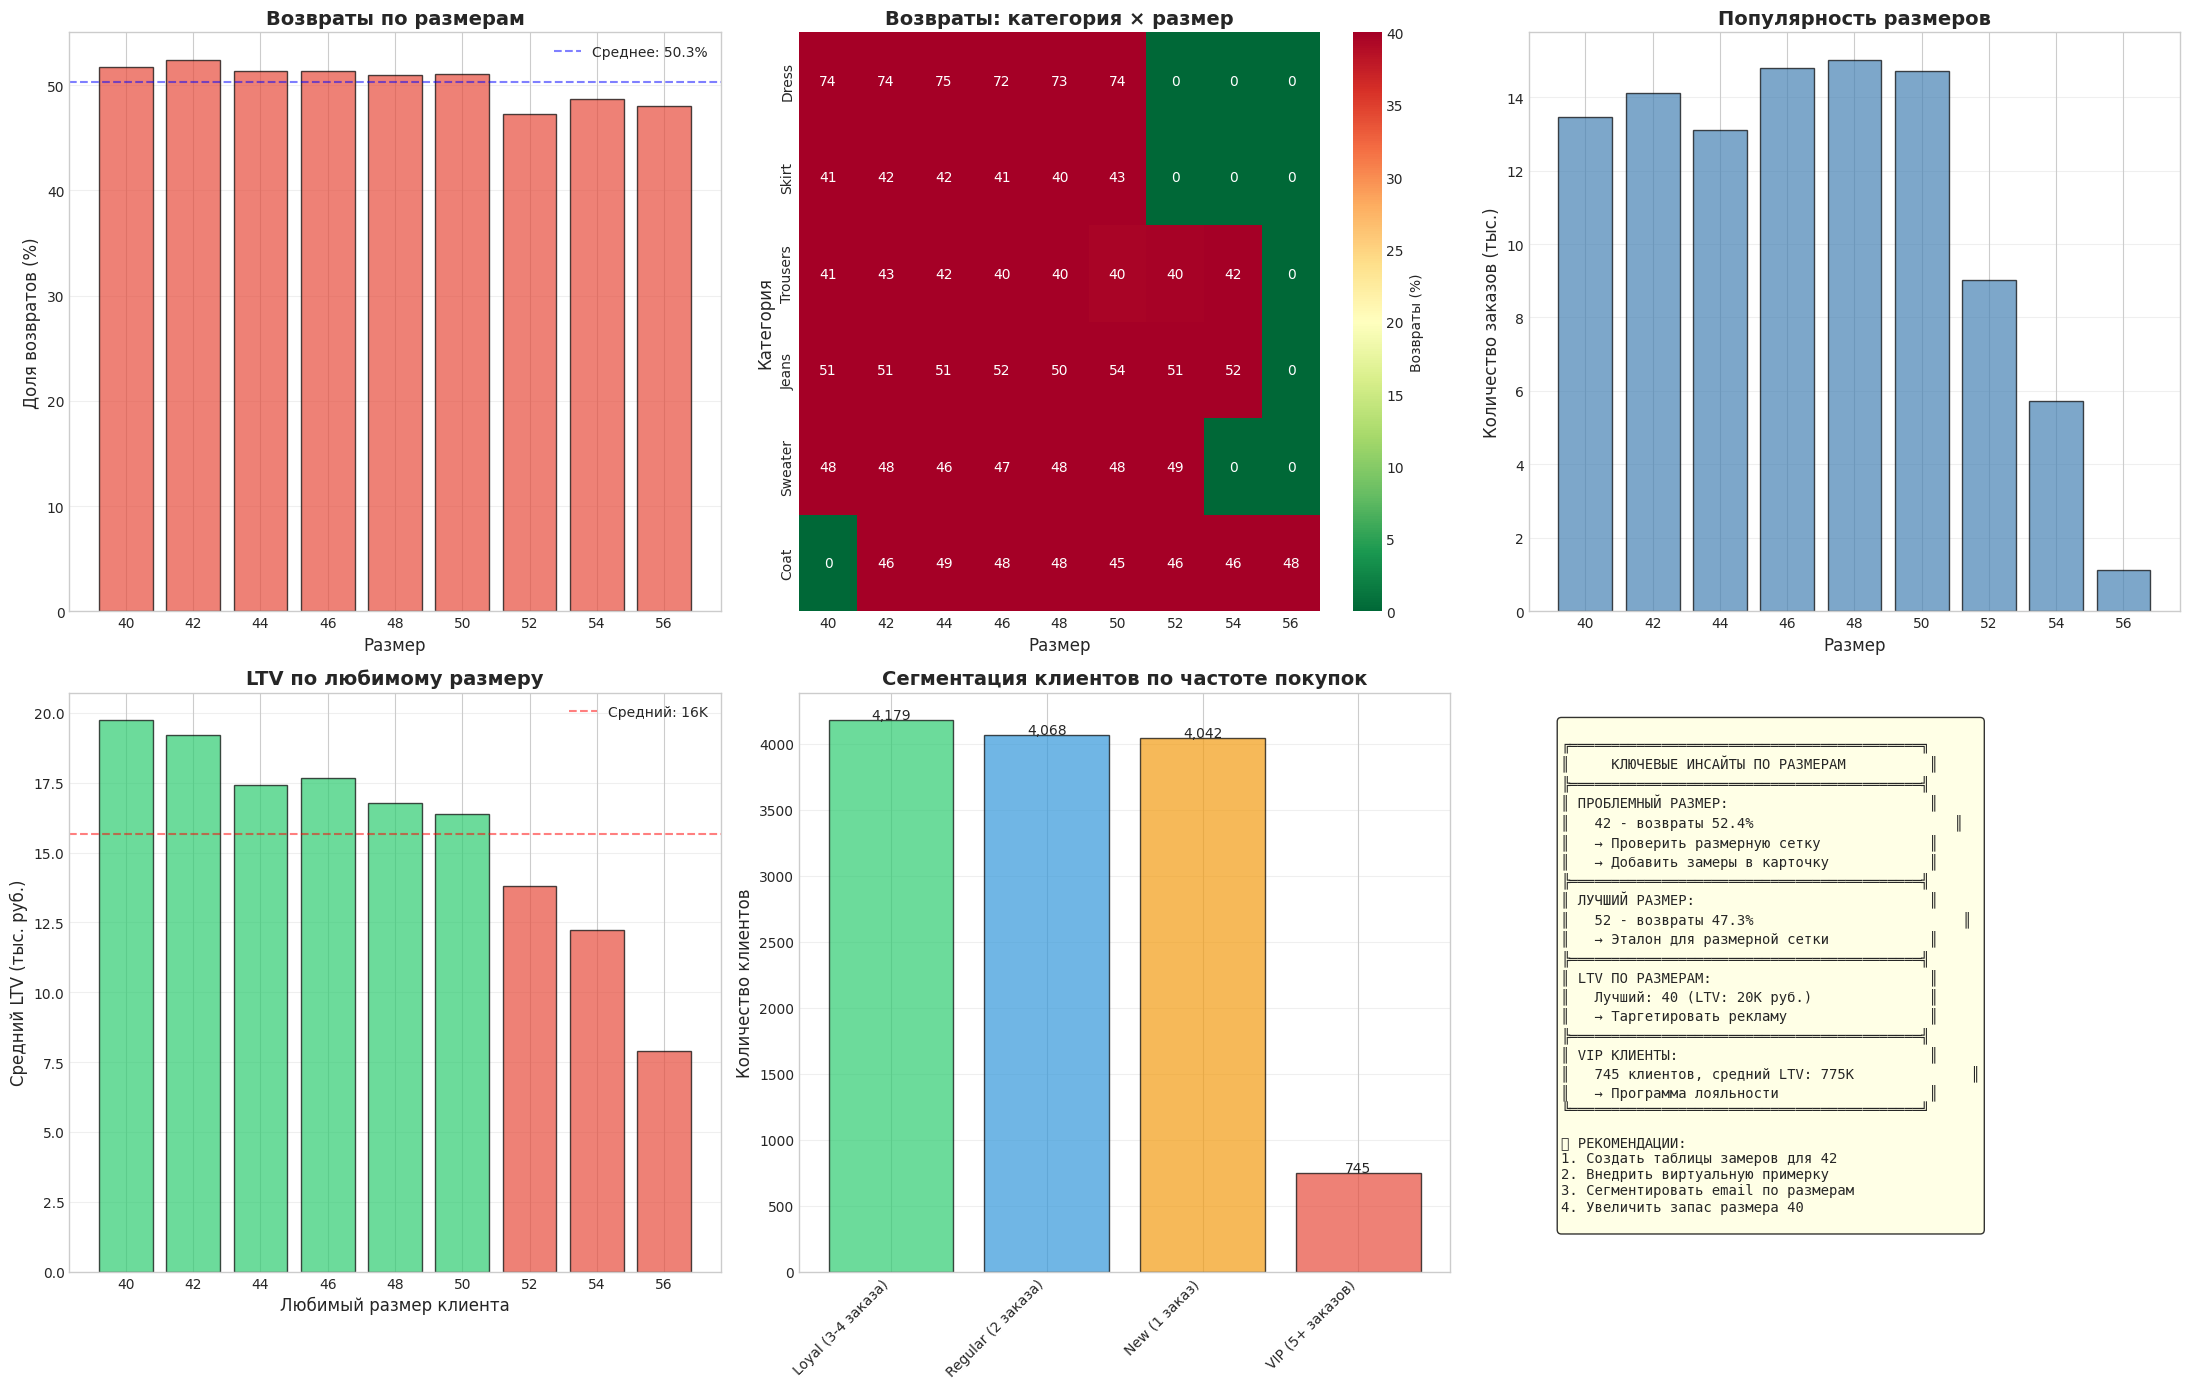

✅ Визуализация сохранена: returns_size_analysis_fixed.png

✅ Результаты сохранены:
   • size_returns.csv
   • size_category_returns.csv
   • customer_ltv_segments.csv
   • ltv_by_favorite_size.csv

АНАЛИЗ ЗАВЕРШЕН!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=" * 80)
print("РАСШИРЕННЫЙ АНАЛИЗ ВОЗВРАТОВ И LTV С УЧЕТОМ РАЗМЕРОВ")
print("ШВЕЙНОЕ ПРОИЗВОДСТВО")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
print("\n📂 Загрузка данных...")

transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')
customers = pd.read_csv('customers.csv', sep=';', encoding='utf-8', decimal=',')

# Проверяем колонки
print(f"\n📊 Колонки в customers: {customers.columns.tolist()}")
print(f"📊 Колонки в transactions: {transactions.columns.tolist()}")

transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
if 'return_date' in transactions.columns:
    transactions['return_date'] = pd.to_datetime(transactions['return_date'])

# Приводим размеры к строке
transactions['size'] = transactions['size'].astype(str)
articles['size'] = articles['size'].astype(str)

# Проверяем наличие typical_size в customers
has_typical_size = 'typical_size' in customers.columns
if has_typical_size:
    customers['typical_size'] = customers['typical_size'].astype(str)
    print("✅ Колонка 'typical_size' найдена")
else:
    print("⚠️ Колонка 'typical_size' НЕ найдена, используем размер из транзакций")

print(f"✅ Данные загружены")

# ============================================
# 2. ВОЗВРАТЫ ПО РАЗМЕРАМ (общий анализ)
# ============================================
print("\n" + "=" * 80)
print("1. АНАЛИЗ ВОЗВРАТОВ ПО РАЗМЕРАМ")
print("=" * 80)

# 2.1 Возвраты по размерам в целом
size_returns = transactions.groupby('size').agg({
    'article_id': 'count',
    'is_returned': 'sum'
}).rename(columns={'article_id': 'total_sales', 'is_returned': 'returns'})

size_returns['return_rate'] = (size_returns['returns'] / size_returns['total_sales'] * 100).round(1)
size_returns = size_returns.sort_values('return_rate', ascending=False)

print("\n📊 ТОП-5 РАЗМЕРОВ ПО ВОЗВРАТАМ:")
print(size_returns.head(5).to_string())

print("\n📊 РАЗМЕРЫ С НАИМЕНЬШИМИ ВОЗВРАТАМИ:")
print(size_returns.tail(5).to_string())

# 2.2 Возвраты по размерам в разрезе категорий
print("\n" + "=" * 80)
print("2. ВОЗВРАТЫ ПО РАЗМЕРАМ × КАТЕГОРИЯМ")
print("=" * 80)

size_category_returns = transactions.groupby(['product_type_name', 'size']).agg({
    'article_id': 'count',
    'is_returned': 'sum'
}).rename(columns={'article_id': 'total_sales', 'is_returned': 'returns'})

size_category_returns['return_rate'] = (size_category_returns['returns'] / size_category_returns['total_sales'] * 100).round(1)

# Находим проблемные комбинации (возвраты > 30%)
problem_combos = size_category_returns[size_category_returns['return_rate'] > 30].sort_values('return_rate', ascending=False)

if len(problem_combos) > 0:
    print("\n🔴 ПРОБЛЕМНЫЕ КОМБИНАЦИИ (возвраты > 30%):")
    print(problem_combos.head(10).to_string())
else:
    print("\n✅ Нет комбинаций с возвратами > 30%")

# ============================================
# 3. АНАЛИЗ ВОЗВРАТОВ ПО КАНАЛАМ ПРОДАЖ И РАЗМЕРАМ
# ============================================
print("\n" + "=" * 80)
print("3. ВОЗВРАТЫ ПО КАНАЛАМ И РАЗМЕРАМ")
print("=" * 80)

if 'sales_channel' in transactions.columns:
    channel_size_returns = transactions.groupby(['sales_channel', 'size']).agg({
        'article_id': 'count',
        'is_returned': 'mean'
    }).rename(columns={'article_id': 'total_sales', 'is_returned': 'return_rate'})

    channel_size_returns['return_rate'] = (channel_size_returns['return_rate'] * 100).round(1)

    print("\n📊 ВОЗВРАТЫ ПО КАНАЛАМ И РАЗМЕРАМ:")
    for channel in channel_size_returns.index.get_level_values(0).unique():
        channel_data = channel_size_returns.loc[channel].sort_values('return_rate', ascending=False)
        print(f"\n   {channel}:")
        for size, row in channel_data.head(3).iterrows():
            if row['total_sales'] > 50:  # Только значимые объемы
                print(f"      • Размер {size}: {row['return_rate']:.1f}% ({row['total_sales']:,} заказов)")

# ============================================
# 4. LTV ПО КЛИЕНТАМ (без typical_size)
# ============================================
print("\n" + "=" * 80)
print("4. АНАЛИЗ LTV КЛИЕНТОВ")
print("=" * 80)

# Считаем LTV для каждого клиента
# Исключаем анонимных клиентов (customer_id = 0)
transactions_filtered = transactions[transactions['customer_id'] != 0].copy()

customer_ltv = transactions_filtered.groupby('customer_id').agg({
    'price': 'sum',
    't_dat': 'count',
    'margin': 'sum'
}).rename(columns={'price': 'ltv', 't_dat': 'orders', 'margin': 'total_margin'})

# Определяем самый часто покупаемый размер для каждого клиента
customer_fav_size = transactions_filtered.groupby(['customer_id', 'size']).size().reset_index(name='count')

customer_fav_size = customer_fav_size.sort_values(['customer_id', 'count'], ascending=[True, False])
customer_fav_size = customer_fav_size.groupby('customer_id').first().reset_index()
customer_fav_size = customer_fav_size[['customer_id', 'size']].rename(columns={'size': 'favorite_size'})

# Объединяем с LTV
customer_ltv = customer_ltv.merge(customer_fav_size, on='customer_id', how='left')

print(f"\n📊 Всего клиентов с покупками: {len(customer_ltv):,}")
print(f"   • Средний LTV: {customer_ltv['ltv'].mean():,.0f} руб.")
print(f"   • Медианный LTV: {customer_ltv['ltv'].median():,.0f} руб.")
print(f"   • Среднее количество заказов: {customer_ltv['orders'].mean():.1f}")

# LTV по favorite_size
ltv_by_size = customer_ltv.groupby('favorite_size').agg({
    'ltv': 'median',  # вместо 'mean'
    'orders': 'median',  # тоже лучше медиана
    'customer_id': 'count'
}).rename(columns={'customer_id': 'customer_count'})


ltv_by_size = customer_ltv.groupby('favorite_size').agg({
    'ltv': 'mean',
    'orders': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'customer_count'})

ltv_by_size = ltv_by_size.dropna().sort_values('ltv', ascending=False)

print("\n📊 СРЕДНИЙ LTV ПО ЛЮБИМОМУ РАЗМЕРУ КЛИЕНТА:")
for size, row in ltv_by_size.head(5).iterrows():
    print(f"   • Размер {size}: {row['ltv']:,.0f} руб. ({row['orders']:.1f} заказов, {row['customer_count']} клиентов)")

# ============================================
# 5. ВОЗВРАТЫ ПО КЛИЕНТСКИМ СЕГМЕНТАМ
# ============================================
print("\n" + "=" * 80)
print("5. СЕГМЕНТАЦИЯ КЛИЕНТОВ ПО ЧАСТОТЕ ПОКУПОК")
print("=" * 80)

# Сегментация по частоте покупок
def segment_by_orders(orders):
    if orders >= 5:
        return 'VIP (5+ заказов)'
    elif orders >= 3:
        return 'Loyal (3-4 заказа)'
    elif orders == 2:
        return 'Regular (2 заказа)'
    else:
        return 'New (1 заказ)'

customer_ltv['segment'] = customer_ltv['orders'].apply(segment_by_orders)

# Возвраты по сегментам и размерам
transactions_with_segment = transactions[transactions['customer_id'] > 0].merge(
    customer_ltv[['customer_id', 'segment']],
    on='customer_id',
    how='left'
)

segment_returns = transactions_with_segment.groupby(['segment', 'size']).agg({
    'is_returned': 'mean',
    'article_id': 'count'
}).round(3)

segment_returns['is_returned'] = segment_returns['is_returned'] * 100

print("\n📊 ВОЗВРАТЫ ПО СЕГМЕНТАМ И РАЗМЕРАМ:")
segments = ['VIP (5+ заказов)', 'Loyal (3-4 заказа)', 'Regular (2 заказа)', 'New (1 заказ)']
for segment in segments:
    if segment in segment_returns.index.get_level_values(0):
        segment_data = segment_returns.loc[segment]
        if len(segment_data) > 0:
            avg_return = segment_data['is_returned'].mean()
            total_orders = segment_data['article_id'].sum()
            print(f"\n   {segment}:")
            print(f"      • Средний возврат: {avg_return:.1f}%")
            print(f"      • Всего заказов: {total_orders:,.0f}")

            # Проблемные размеры в сегменте
            if len(segment_data) > 0:
                worst_size = segment_data['is_returned'].idxmax()
                worst_rate = segment_data['is_returned'].max()
                print(f"      • Худший размер: {worst_size} ({worst_rate:.1f}%)")

# ============================================
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================
print("\n" + "=" * 80)
print("6. ВИЗУАЛИЗАЦИЯ")
print("=" * 80)

fig = plt.figure(figsize=(22, 14))

# 6.1 Возвраты по размерам (общий)
ax1 = plt.subplot(2, 3, 1)
size_returns_sorted = size_returns.sort_index()
colors = ['#e74c3c' if x > 20 else '#f39c12' if x > 10 else '#2ecc71'
          for x in size_returns_sorted['return_rate']]
bars = ax1.bar(range(len(size_returns_sorted)), size_returns_sorted['return_rate'],
               color=colors, edgecolor='black', alpha=0.7)
ax1.set_xticks(range(len(size_returns_sorted)))
ax1.set_xticklabels(size_returns_sorted.index)
ax1.set_xlabel('Размер', fontsize=12)
ax1.set_ylabel('Доля возвратов (%)', fontsize=12)
ax1.set_title('Возвраты по размерам', fontsize=14, fontweight='bold')
ax1.axhline(y=size_returns['return_rate'].mean(), color='blue', linestyle='--',
            alpha=0.5, label=f"Среднее: {size_returns['return_rate'].mean():.1f}%")
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 6.2 Тепловая карта: размер × категория
ax2 = plt.subplot(2, 3, 2)
pivot_size_cat = size_category_returns.reset_index().pivot_table(
    index='product_type_name',
    columns='size',
    values='return_rate',
    fill_value=0
)

# Оставляем топ-6 категорий по продажам
top_cats = transactions['product_type_name'].value_counts().head(6).index
pivot_size_cat = pivot_size_cat.reindex([c for c in top_cats if c in pivot_size_cat.index])

sns.heatmap(pivot_size_cat, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax2,
            cbar_kws={'label': 'Возвраты (%)'}, vmax=40)
ax2.set_title('Возвраты: категория × размер', fontsize=14, fontweight='bold')
ax2.set_xlabel('Размер', fontsize=12)
ax2.set_ylabel('Категория', fontsize=12)

# 6.3 Распределение заказов по размерам
ax3 = plt.subplot(2, 3, 3)
size_sales = size_returns_sorted['total_sales']
bars = ax3.bar(range(len(size_sales)), size_sales.values/1000,
               color='steelblue', edgecolor='black', alpha=0.7)
ax3.set_xticks(range(len(size_sales)))
ax3.set_xticklabels(size_sales.index)
ax3.set_xlabel('Размер', fontsize=12)
ax3.set_ylabel('Количество заказов (тыс.)', fontsize=12)
ax3.set_title('Популярность размеров', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 6.4 LTV по любимому размеру
ax4 = plt.subplot(2, 3, 4)
if len(ltv_by_size) > 0:
    ltv_sorted = ltv_by_size.sort_index()
    colors_ltv = ['#2ecc71' if x > ltv_by_size['ltv'].mean() else '#e74c3c'
                  for x in ltv_sorted['ltv']]
    bars = ax4.bar(range(len(ltv_sorted)), ltv_sorted['ltv']/1000,
                   color=colors_ltv, edgecolor='black', alpha=0.7)
    ax4.set_xticks(range(len(ltv_sorted)))
    ax4.set_xticklabels(ltv_sorted.index)
    ax4.set_xlabel('Любимый размер клиента', fontsize=12)
    ax4.set_ylabel('Средний LTV (тыс. руб.)', fontsize=12)
    ax4.set_title('LTV по любимому размеру', fontsize=14, fontweight='bold')
    ax4.axhline(y=ltv_by_size['ltv'].mean()/1000, color='red', linestyle='--',
                alpha=0.5, label=f"Средний: {ltv_by_size['ltv'].mean()/1000:.0f}K")
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

# 6.5 Сегментация клиентов
ax5 = plt.subplot(2, 3, 5)
segment_counts = customer_ltv['segment'].value_counts()
colors_seg = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax5.bar(range(len(segment_counts)), segment_counts.values,
               color=colors_seg[:len(segment_counts)], edgecolor='black', alpha=0.7)
ax5.set_xticks(range(len(segment_counts)))
ax5.set_xticklabels(segment_counts.index, rotation=45, ha='right')
ax5.set_ylabel('Количество клиентов', fontsize=12)
ax5.set_title('Сегментация клиентов по частоте покупок', fontsize=14, fontweight='bold')
for bar, val in zip(bars, segment_counts.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')

# 6.6 Выводы и рекомендации
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Собираем ключевые инсайты
worst_size = size_returns.index[0] if len(size_returns) > 0 else 'N/A'
worst_size_rate = size_returns.iloc[0]['return_rate'] if len(size_returns) > 0 else 0
best_size = size_returns.index[-1] if len(size_returns) > 0 else 'N/A'
best_size_rate = size_returns.iloc[-1]['return_rate'] if len(size_returns) > 0 else 0

if len(ltv_by_size) > 0:
    best_ltv_size = ltv_by_size.index[0]
    best_ltv_value = ltv_by_size.iloc[0]['ltv']
else:
    best_ltv_size = 'N/A'
    best_ltv_value = 0

vip_count = len(customer_ltv[customer_ltv['segment'] == 'VIP (5+ заказов)'])
vip_ltv = customer_ltv[customer_ltv['segment'] == 'VIP (5+ заказов)']['ltv'].mean()

summary_text = f"""
╔══════════════════════════════════════════╗
║     КЛЮЧЕВЫЕ ИНСАЙТЫ ПО РАЗМЕРАМ          ║
╠══════════════════════════════════════════╣
║ ПРОБЛЕМНЫЙ РАЗМЕР:                        ║
║   {worst_size} - возвраты {worst_size_rate:.1f}%                        ║
║   → Проверить размерную сетку             ║
║   → Добавить замеры в карточку            ║
╠══════════════════════════════════════════╣
║ ЛУЧШИЙ РАЗМЕР:                            ║
║   {best_size} - возвраты {best_size_rate:.1f}%                         ║
║   → Эталон для размерной сетки            ║
╠══════════════════════════════════════════╣
║ LTV ПО РАЗМЕРАМ:                          ║
║   Лучший: {best_ltv_size} (LTV: {best_ltv_value/1000:.0f}K руб.)              ║
║   → Таргетировать рекламу                 ║
╠══════════════════════════════════════════╣
║ VIP КЛИЕНТЫ:                              ║
║   {vip_count} клиентов, средний LTV: {vip_ltv/1000:.0f}K              ║
║   → Программа лояльности                  ║
╚══════════════════════════════════════════╝

📌 РЕКОМЕНДАЦИИ:
1. Создать таблицы замеров для {worst_size}
2. Внедрить виртуальную примерку
3. Сегментировать email по размерам
4. Увеличить запас размера {best_ltv_size}
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('returns_size_analysis_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Визуализация сохранена: returns_size_analysis_fixed.png")

# ============================================
# 7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
size_returns.to_csv('size_returns.csv', encoding='utf-8-sig', sep=';', decimal=',')
size_category_returns.to_csv('size_category_returns.csv', encoding='utf-8-sig', sep=';', decimal=',')
customer_ltv.to_csv('customer_ltv_segments.csv', encoding='utf-8-sig', sep=';', decimal=',')
ltv_by_size.to_csv('ltv_by_favorite_size.csv', encoding='utf-8-sig', sep=';', decimal=',')

print("\n✅ Результаты сохранены:")
print("   • size_returns.csv")
print("   • size_category_returns.csv")
print("   • customer_ltv_segments.csv")
print("   • ltv_by_favorite_size.csv")

print("\n" + "=" * 80)
print("АНАЛИЗ ЗАВЕРШЕН!")
print("=" * 80)
